# 01 - Exploratory Data Analysis (EDA)

## Phát hiện Giao dịch Gian lận dựa trên Mạng Neural Đồ thị

Notebook này thực hiện phân tích khám phá dữ liệu IEEE-CIS Fraud Detection:
- Phân phối lớp (Fraud vs Non-Fraud)
- Phân phối số tiền giao dịch
- Giá trị thiếu (Missing Values)
- Phân phối theo thời gian
- Ma trận tương quan
- Phân tích fraud rate theo category

In [1]:
import sys
sys.path.insert(0, '..')

from src.config import set_seed
from src.data_loader import IEEECISDataLoader
from src.eda import EDAAnalyzer

set_seed(42)

## 1. Load dữ liệu

In [2]:
loader = IEEECISDataLoader()
df = loader.load()


LOADING DATA
Loaded 590,540 transactions
Fraud rate: 3.50% (20,663 fraud transactions)
txn_index range: 0 to 590539
Columns: ['txn_index', 'TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'DeviceType', 'id_30', 'id_31']
[load] completed in 1.25s


## 2. Thống kê tổng quan

In [3]:
# Thống kê fraud
fraud_stats = loader.get_fraud_stats()
print("Fraud Statistics:")
for key, value in fraud_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value:,}")

Fraud Statistics:
  total_transactions: 590,540
  fraud_count: 20,663
  non_fraud_count: 569,877
  fraud_rate: 0.0350
  imbalance_ratio: 27.5796


In [4]:
# Thống kê giá trị thiếu
missing_stats = loader.get_missing_stats()
print(missing_stats)

shape: (19, 3)
┌────────────────┬────────────┬─────────────────┐
│ column         ┆ null_count ┆ null_percentage │
│ ---            ┆ ---        ┆ ---             │
│ str            ┆ i64        ┆ f64             │
╞════════════════╪════════════╪═════════════════╡
│ id_30          ┆ 512975     ┆ 86.865411       │
│ DeviceInfo     ┆ 471874     ┆ 79.90551        │
│ R_emaildomain  ┆ 453249     ┆ 76.751617       │
│ id_31          ┆ 450258     ┆ 76.245132       │
│ DeviceType     ┆ 449730     ┆ 76.155722       │
│ …              ┆ …          ┆ …               │
│ TransactionID  ┆ 0          ┆ 0.0             │
│ isFraud        ┆ 0          ┆ 0.0             │
│ TransactionDT  ┆ 0          ┆ 0.0             │
│ TransactionAmt ┆ 0          ┆ 0.0             │
│ card1          ┆ 0          ┆ 0.0             │
└────────────────┴────────────┴─────────────────┘


## 3. Chạy toàn bộ EDA

In [5]:
analyzer = EDAAnalyzer(df)
analyzer.run_all()

Running Full EDA Analysis
Plotting class distribution...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\class_distribution.png
Plotting transaction amount distribution...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\transaction_amount_distribution.png
Plotting missing values...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\missing_values.png
Plotting transaction time distribution...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\transaction_time.png
Plotting correlation matrix...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\correlation_matrix.png
Plotting fraud rate by card4...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\fraud_by_card4.png
Plotting fraud rate by card6...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\fraud_by_card6.png
Plotting fraud rate by DeviceType...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\fraud_by_devicetype.png
Plotting fraud rate by P_emaildomain...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\eda\fraud_by_p_emaildomain.png

All EDA plots saved to:

## 4. Hiển thị từng biểu đồ

Các biểu đồ đã được lưu tự động vào `output/eda/`. Có thể xem bằng cách load lại:


--- class_distribution ---


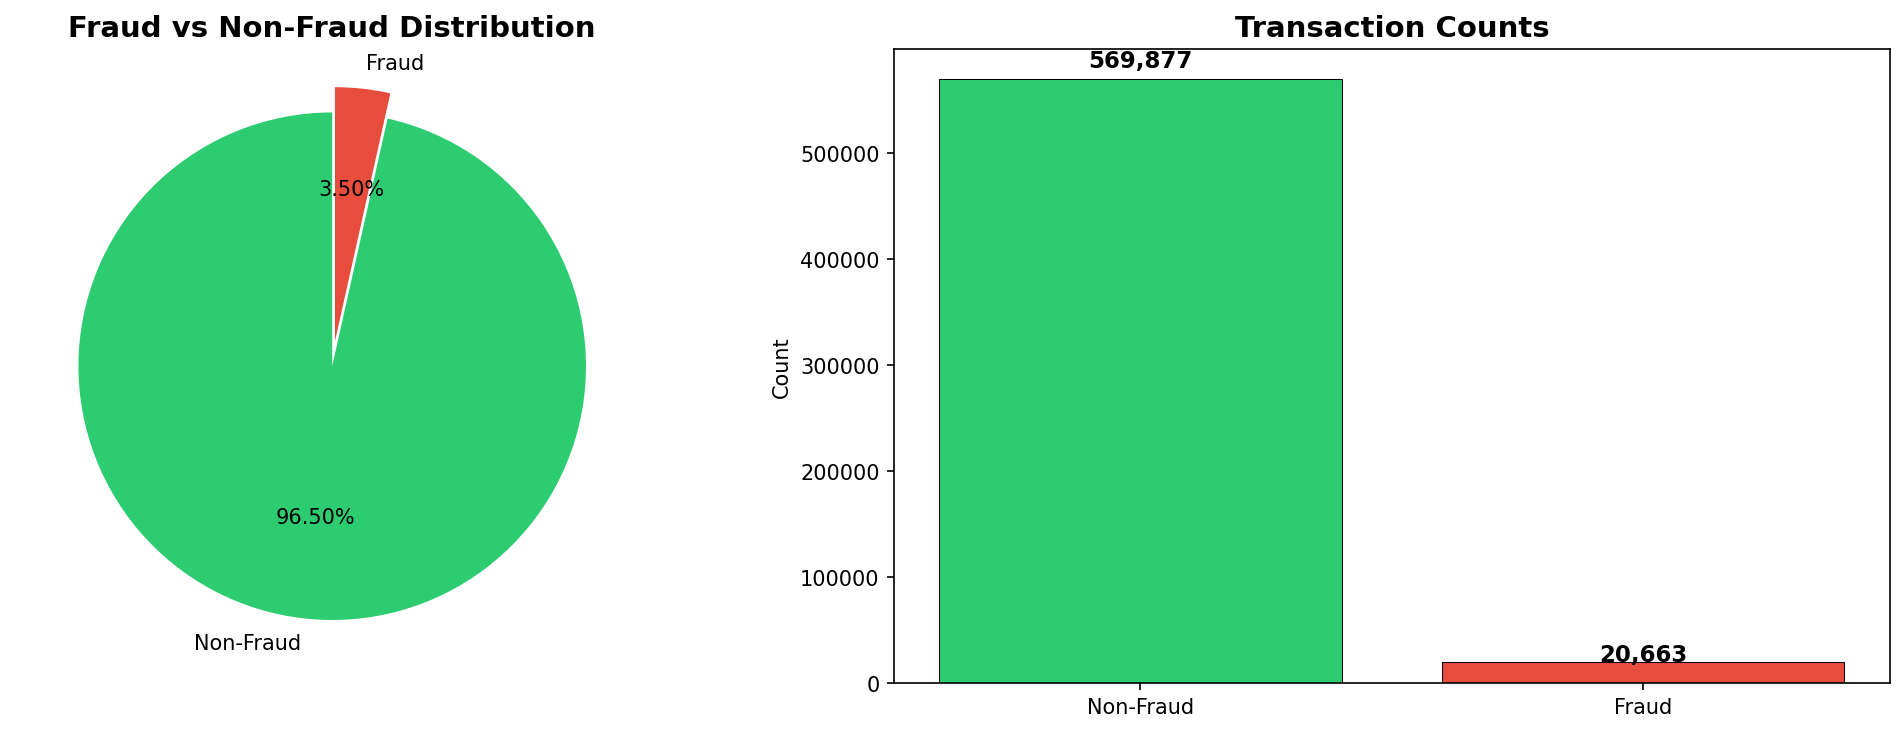


--- correlation_matrix ---


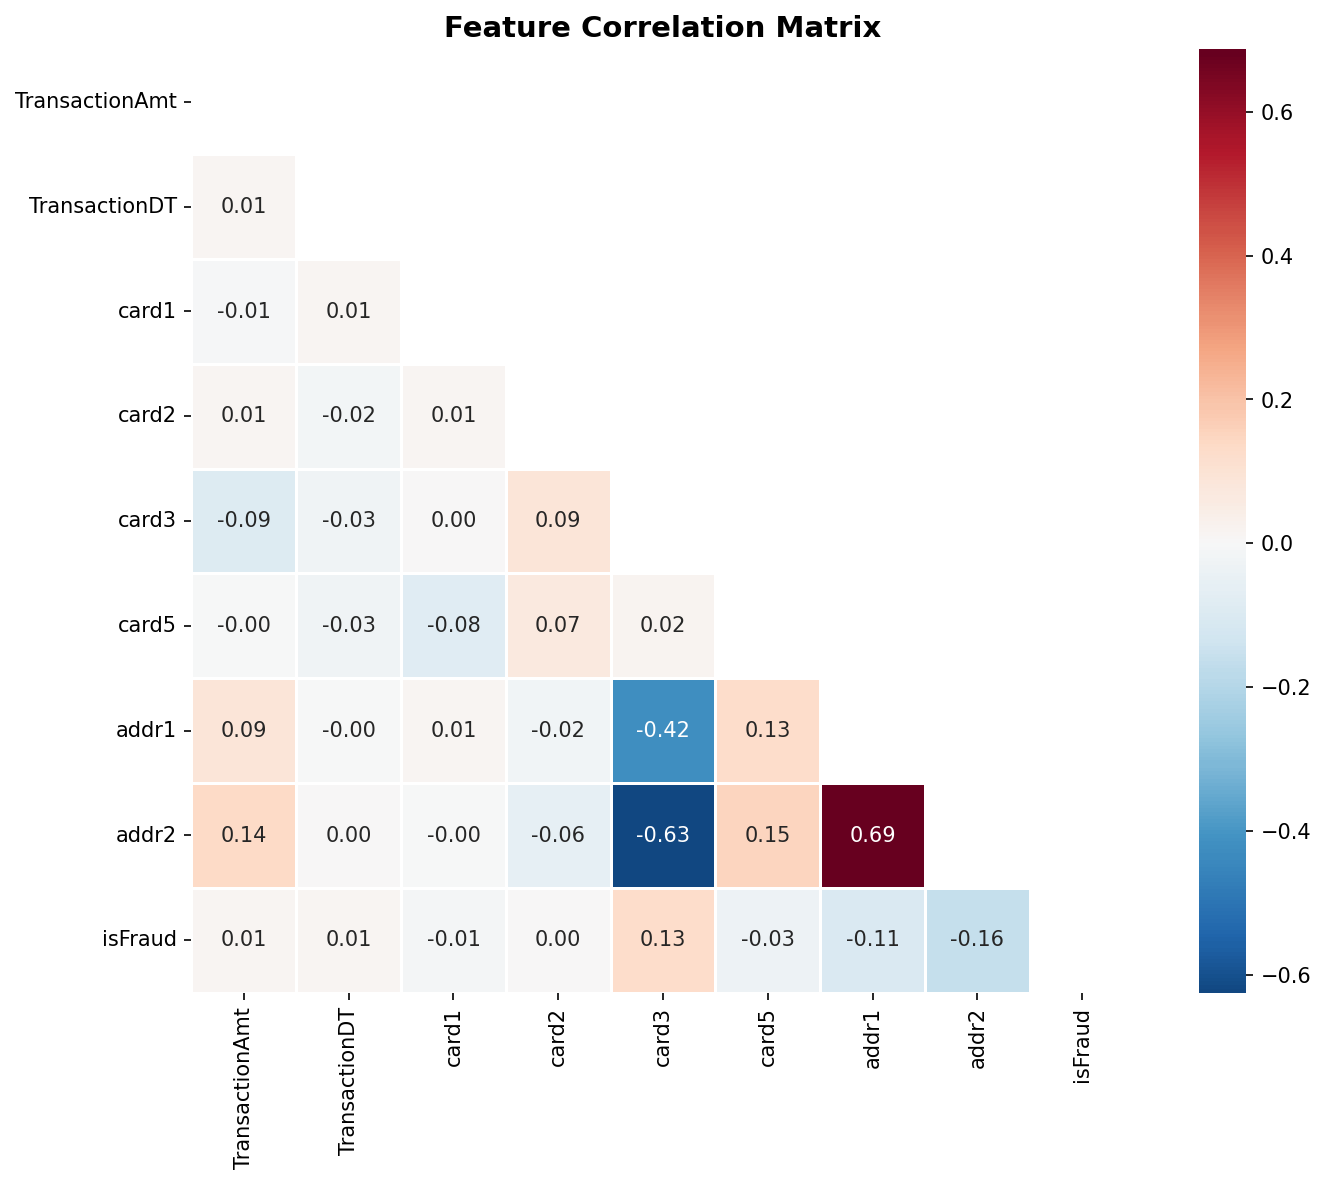


--- fraud_by_card4 ---


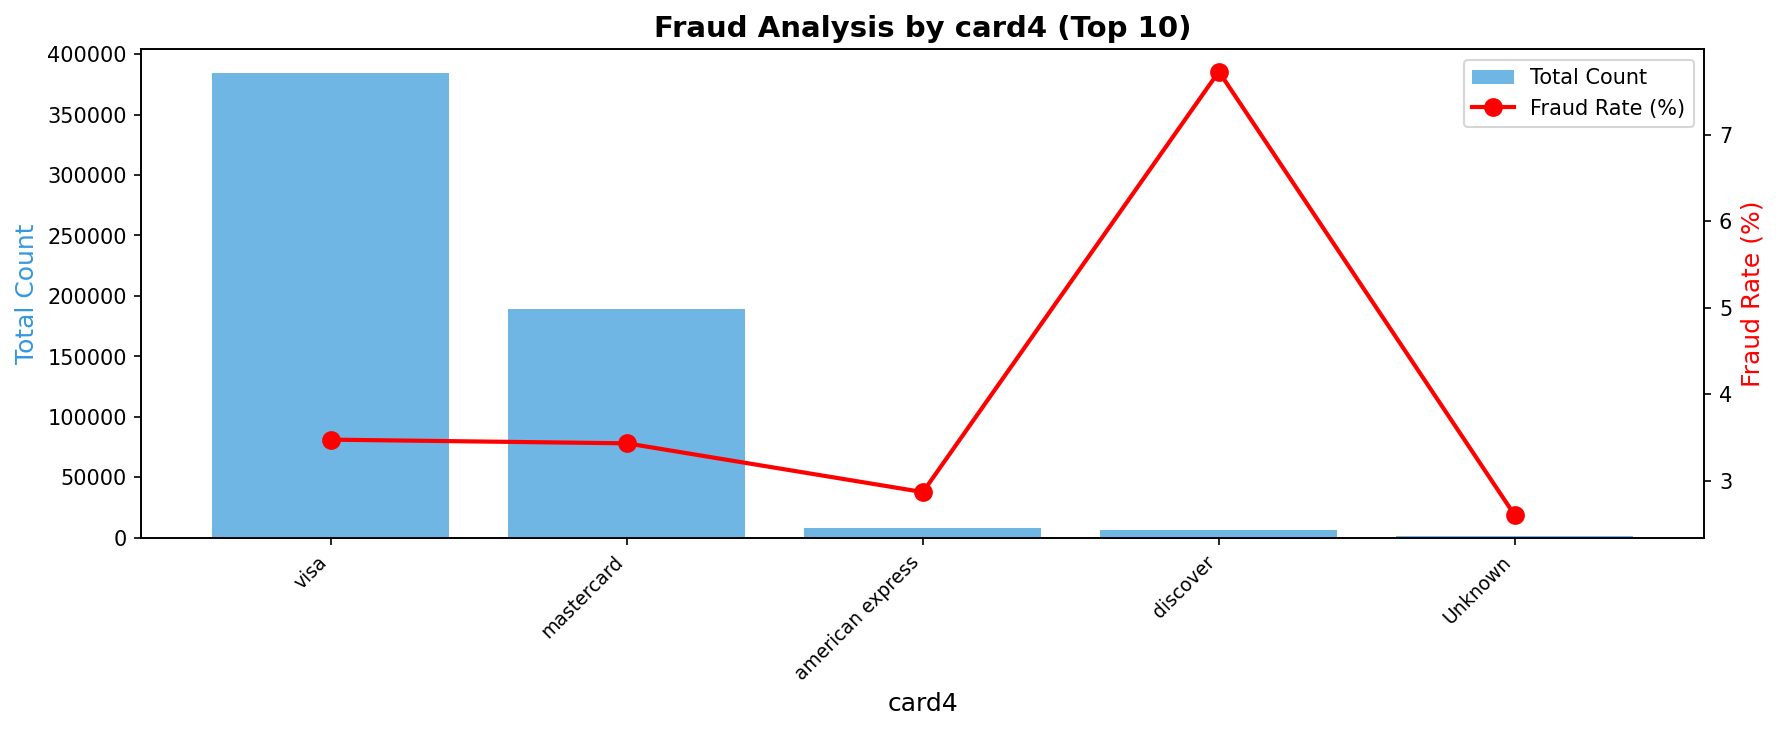


--- fraud_by_card6 ---


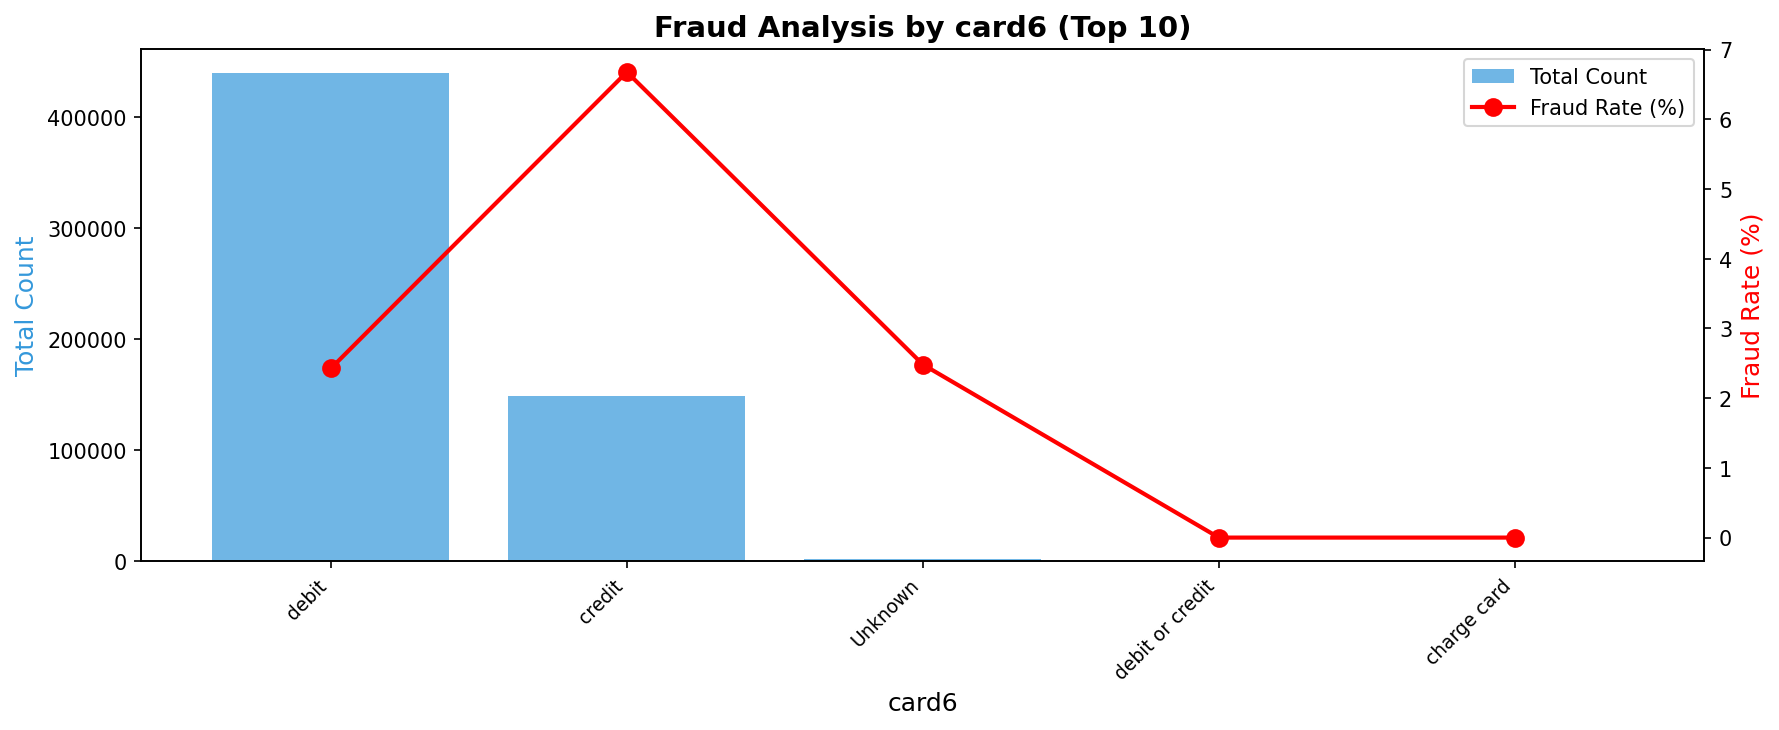


--- fraud_by_devicetype ---


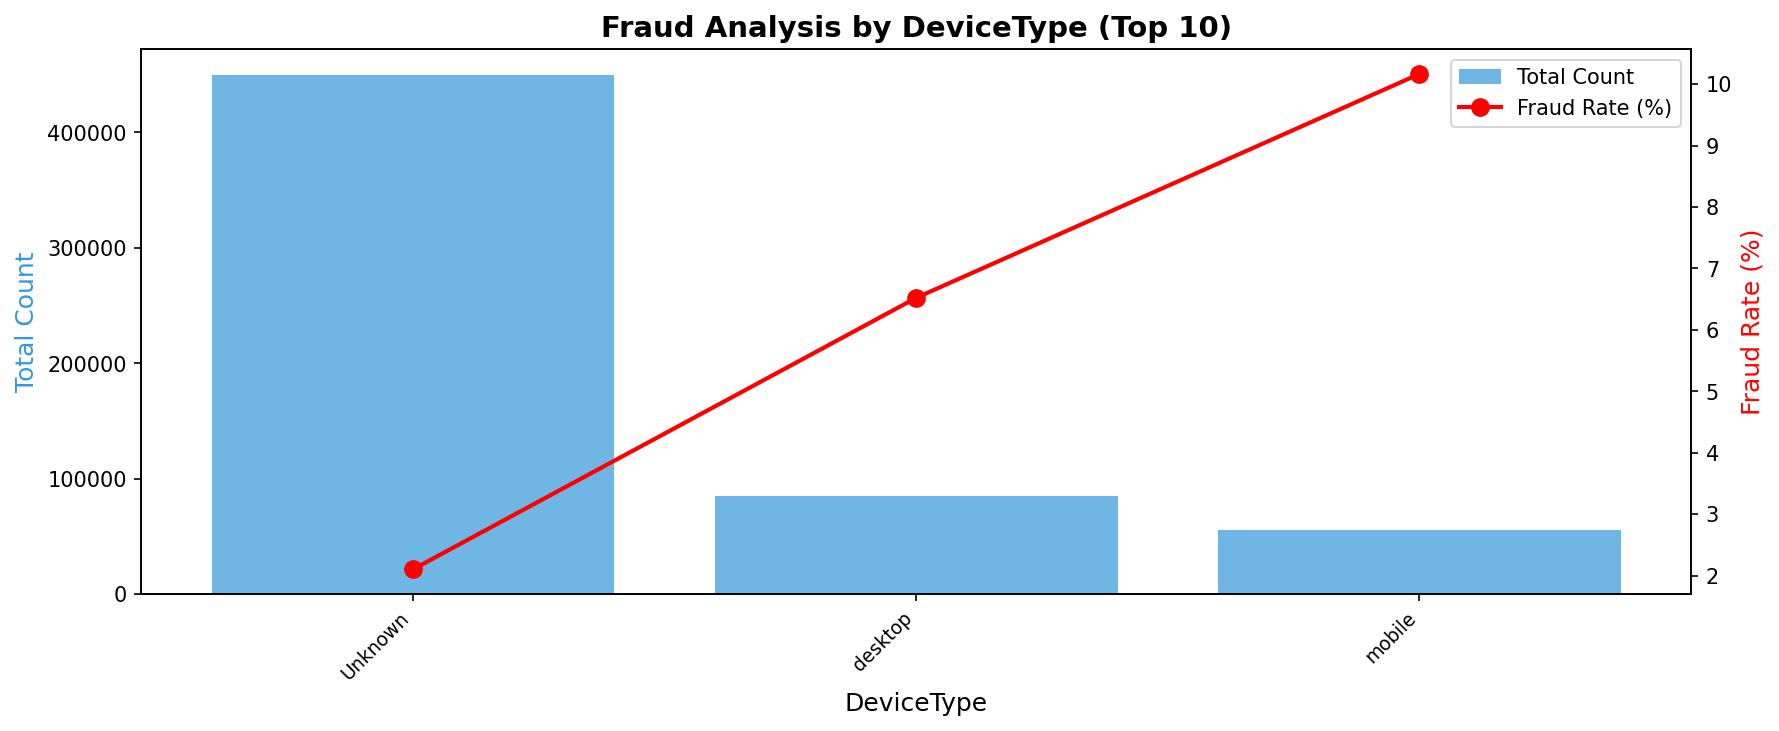


--- fraud_by_p_emaildomain ---


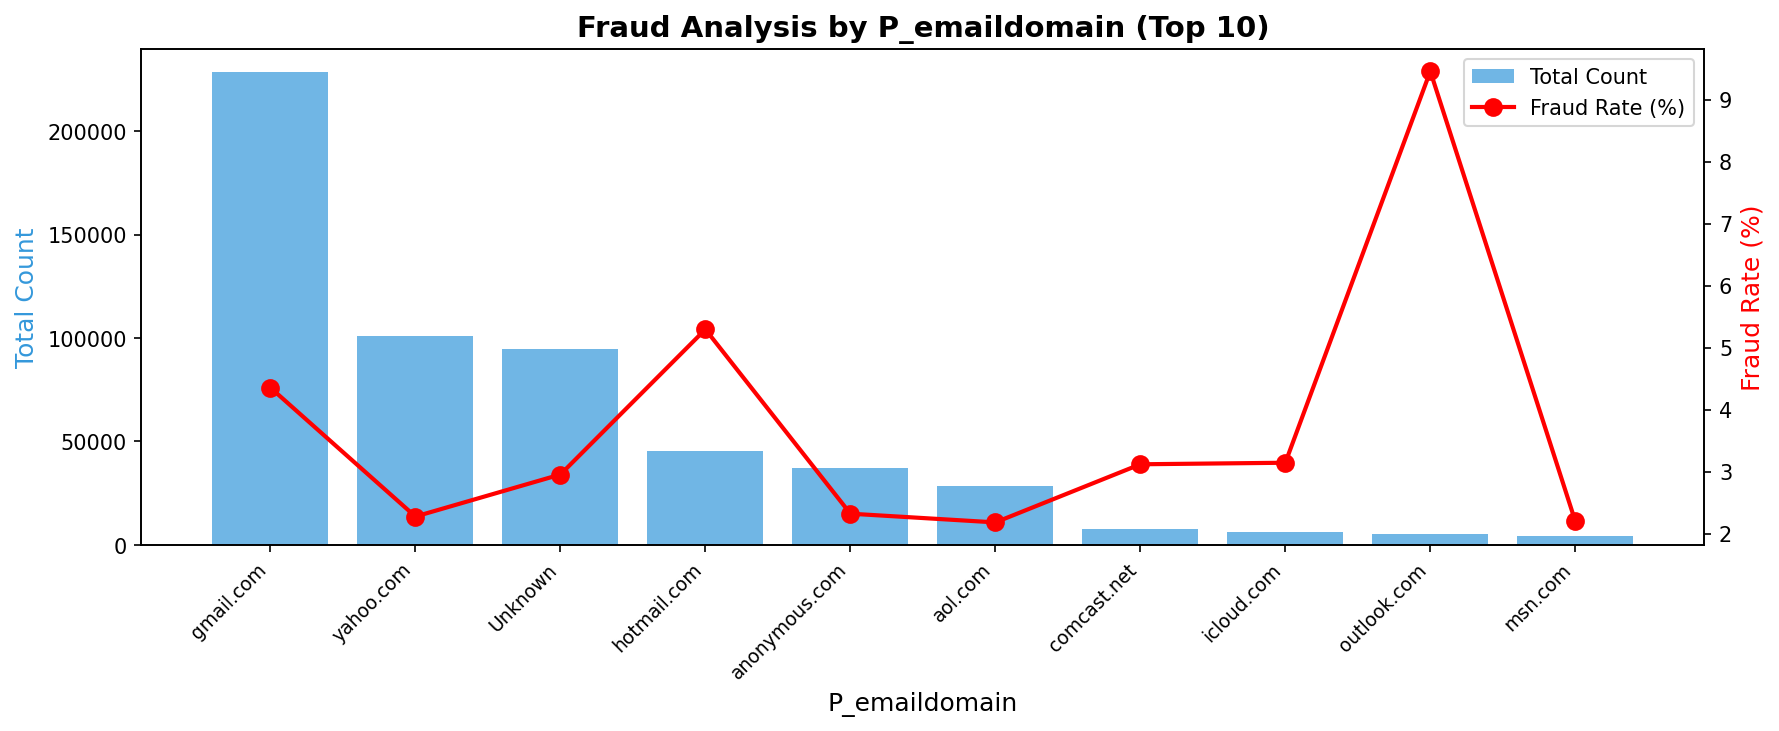


--- missing_values ---


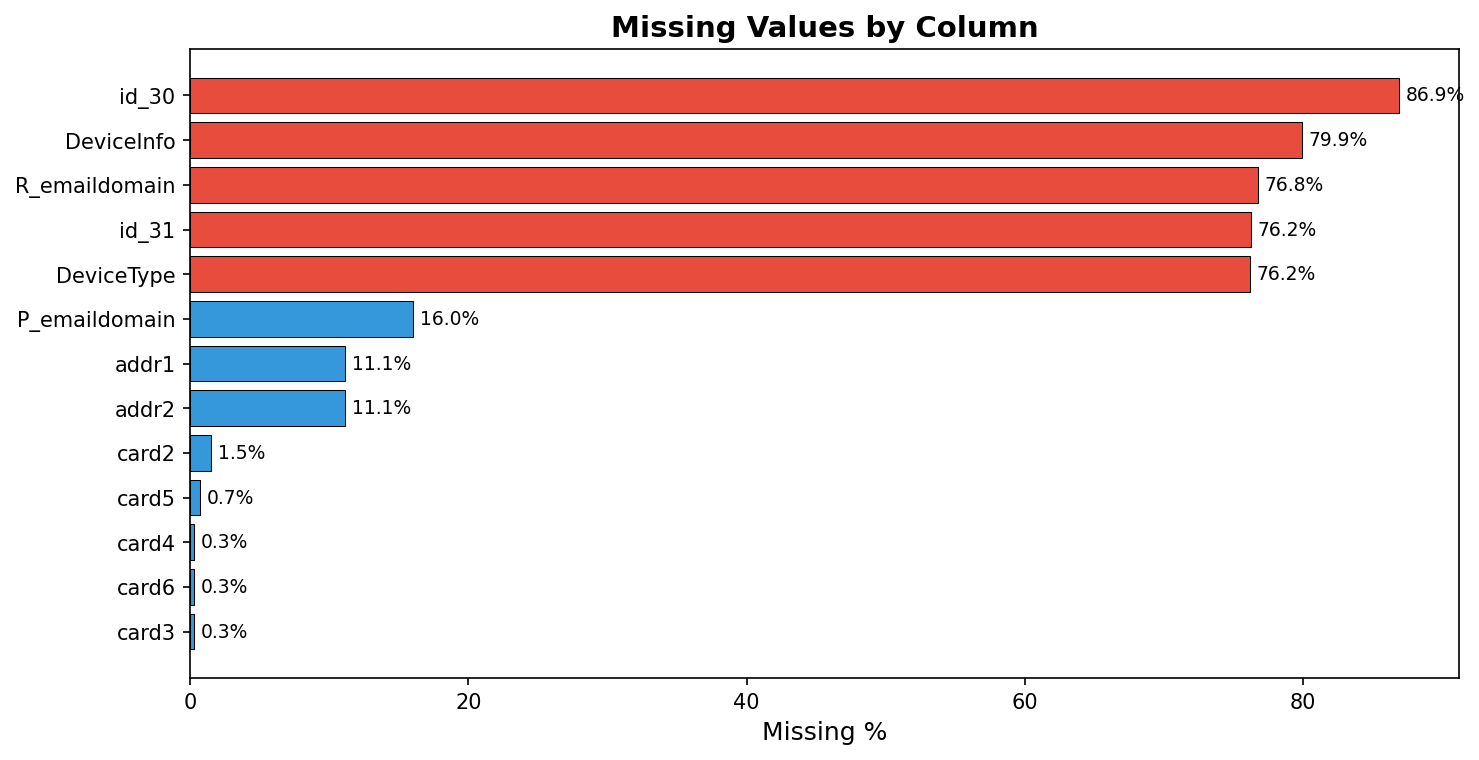


--- transaction_amount_distribution ---


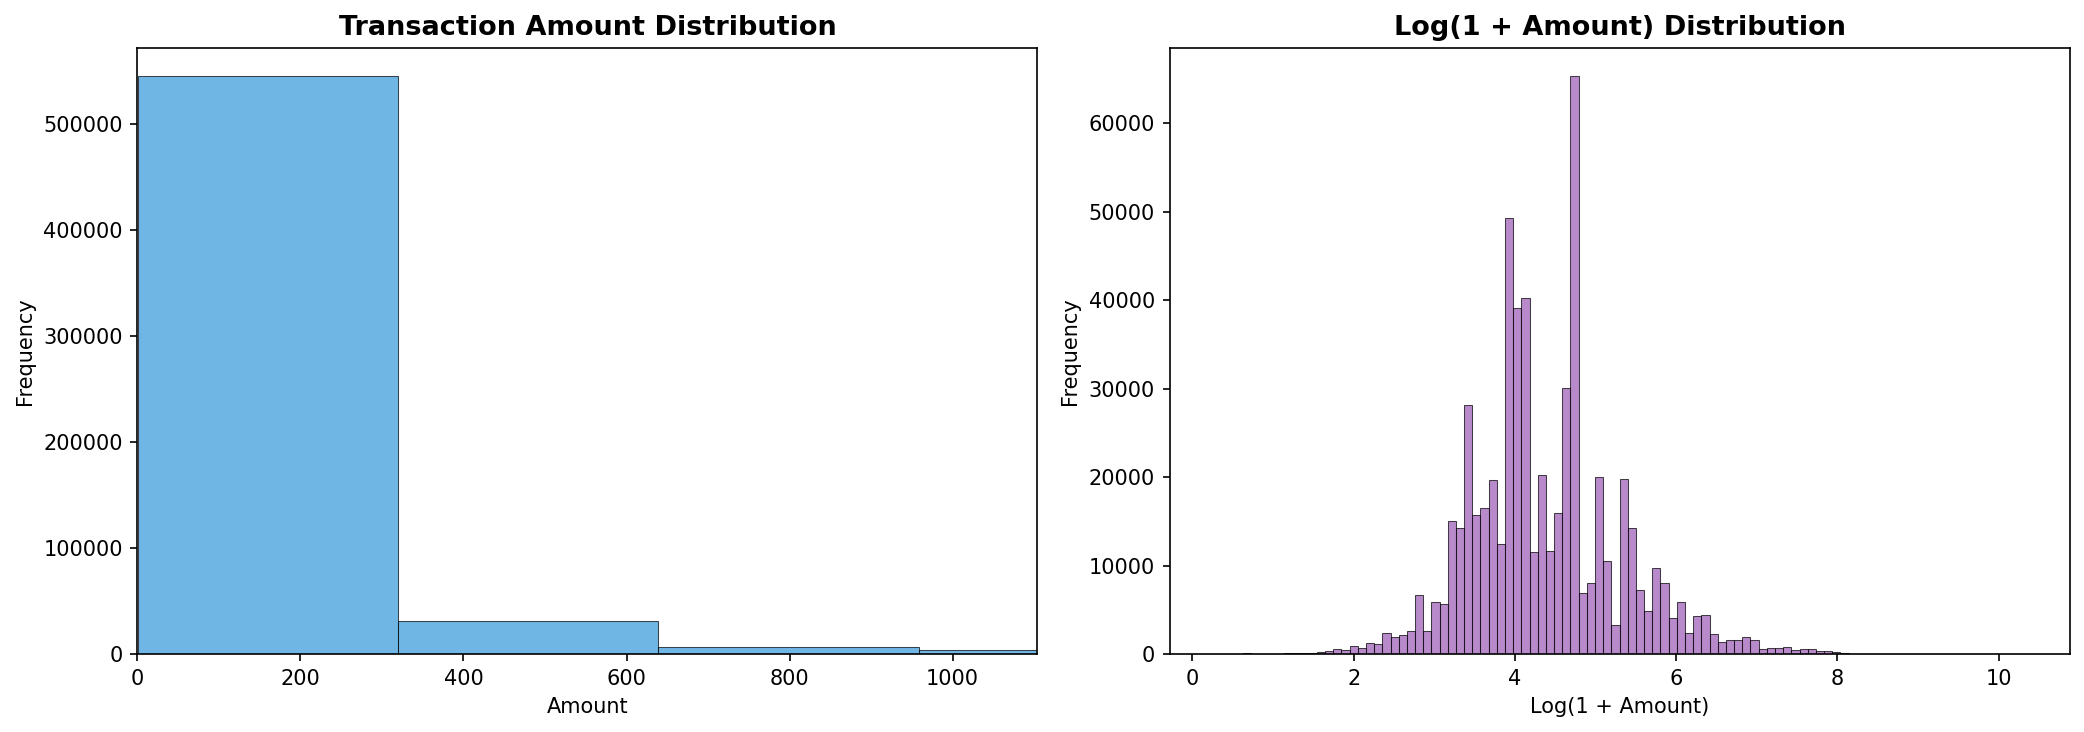


--- transaction_time ---


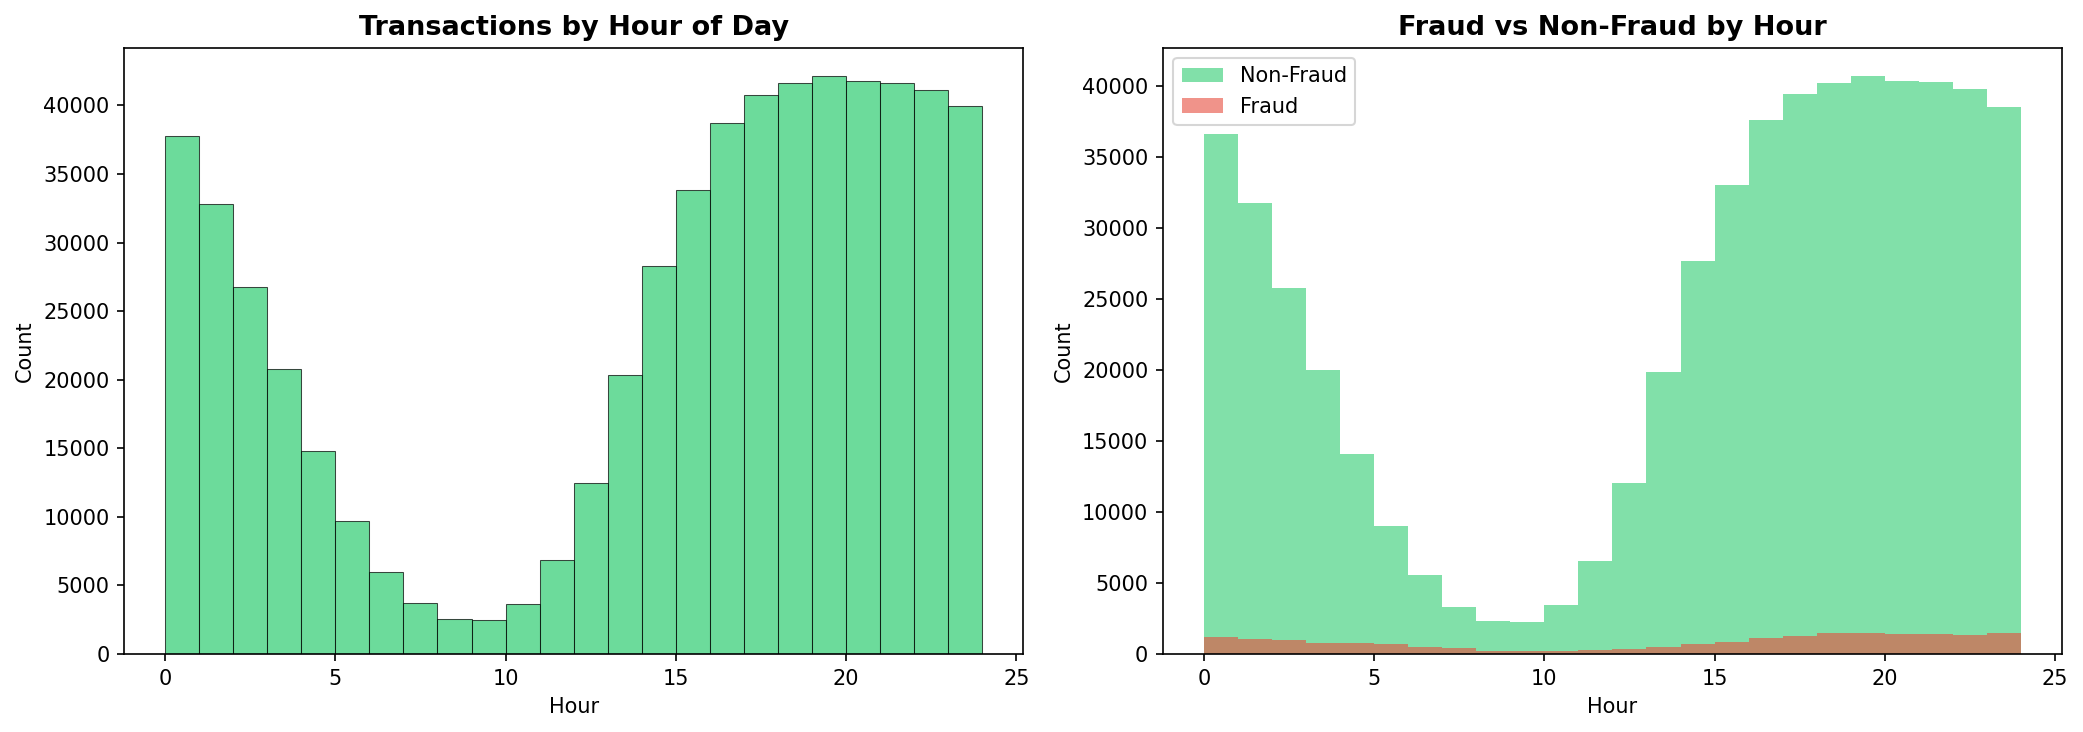

In [6]:
from IPython.display import Image, display
from pathlib import Path

eda_dir = Path('../output/eda')
for img_path in sorted(eda_dir.glob('*.png')):
    print(f"\n--- {img_path.stem} ---")
    display(Image(filename=str(img_path), width=700))